# IntelliPulse V8 — Model Performance Monitoring

**Experiment**: Evaluate whether the frozen XGBoost model's predictive performance has degraded on new labeled data.

| Component | Value |
|---|---|
| **Frozen Model** | `churn_xgboost_v4_tuned.joblib` (V4) |
| **Frozen Threshold** | 0.29 (V5) |
| **Evaluation Data** | Held-out test set (1,409 rows) |
| **Scenarios** | Stable, Moderate Shift, Strong Shift |
| **Primary Metric** | F1 Score |
| **Degradation Rule** | F1 drop ≥ 10% → DEGRADED |

---
## 1. V8 Objective

### Data Drift vs. Model Performance Degradation

**Data drift** (V7) detects whether the *statistical distribution of input features* has changed relative to the training baseline. It answers: *"Has the incoming data changed?"*

**Model performance degradation** (V8) measures whether the model's *predictive accuracy on actual outcomes* has declined. It answers: *"Has the model become less effective at predicting churn?"*

### Why drift does NOT automatically mean model failure

A model may continue to perform well even when input distributions shift — for example, if the shift occurs in features the model does not heavily rely on, or if the decision boundary remains valid in the shifted region. Conversely, subtle shifts in critical features may degrade performance without triggering dramatic drift alerts.

**Drift is a signal, not a verdict.**

### Why actual labels are required for performance metrics

- **Accuracy, Precision, Recall, and F1** all require comparing predictions against *ground truth labels* (`y_true`)
- Without labels, we can only measure *how confidently* the model predicts, not *how correctly*
- V7.2 batches are production-style and contain **no target label** — they cannot be used for true performance measurement

### V7 vs V8 Architecture

```
V7 (Data Drift Detection):
X → statistical comparison → drift detected?

V8 (Model Performance Monitoring):
X + y → frozen model → predictions → compare with y → performance metrics
```

V7 and V8 are complementary: V7 watches for input changes, V8 watches for outcome degradation.

---
## 2. Load Existing Pipeline

Reuse the frozen V4 XGBoost model (full sklearn Pipeline with preprocessor + classifier) and the V5 optimized threshold of 0.29. No retraining or modification.

In [1]:
import os
import json
import hashlib
from pathlib import Path
from datetime import datetime
from copy import deepcopy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
)

# ── Configuration ────────────────────────────────────────────────────
RANDOM_STATE = 42
THRESHOLD = 0.29

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({
    "figure.figsize": (10, 6),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
})

PROJECT_ROOT = Path.cwd().parent
RAW_DATA_PATH = PROJECT_ROOT / "data" / "raw" / "WA_Fn-UseC_-Telco-Customer-Churn.csv"
MODEL_DIR = PROJECT_ROOT / "artifacts" / "models"
METRICS_DIR = PROJECT_ROOT / "artifacts" / "metrics"
MONITORING_DIR = PROJECT_ROOT / "artifacts" / "monitoring"

print(f"Project root : {PROJECT_ROOT}")
print(f"Threshold    : {THRESHOLD}")
print(f"Random state : {RANDOM_STATE}")

Project root : /Users/shubhamswaraj/Desktop/PLACEMENT/IntelliPulse
Threshold    : 0.29
Random state : 42


In [2]:
# ── Load frozen XGBoost model (V4 — full pipeline) ────────────────────
MODEL_PATH = MODEL_DIR / "churn_xgboost_v4_tuned.joblib"
assert MODEL_PATH.exists(), f"Model not found at {MODEL_PATH}"

model_v4 = joblib.load(MODEL_PATH)

# Compute model hash for integrity verification later
model_hash_before = hashlib.sha256(open(MODEL_PATH, "rb").read()).hexdigest()

# ── Validate pipeline structure ───────────────────────────────────────
assert hasattr(model_v4, "named_steps"), "Model is not a sklearn Pipeline!"
assert "preprocessor" in model_v4.named_steps, "Missing preprocessor step!"
assert "classifier" in model_v4.named_steps, "Missing classifier step!"

preprocessor = model_v4.named_steps["preprocessor"]
classifier = model_v4.named_steps["classifier"]

print("✓ Frozen model loaded successfully")
print(f"  Pipeline steps : {list(model_v4.named_steps.keys())}")
print(f"  Classifier     : {type(classifier).__name__}")
print(f"  Model hash     : {model_hash_before[:16]}...")
print(f"  Threshold      : {THRESHOLD}")

✓ Frozen model loaded successfully
  Pipeline steps : ['preprocessor', 'classifier']
  Classifier     : XGBClassifier
  Model hash     : aa144ecf6b7844e4...
  Threshold      : 0.29


In [3]:
# ── Load feature definitions ──────────────────────────────────────────
feat_def_path = METRICS_DIR / "feature_definitions_v1.json"
with open(feat_def_path) as f:
    feature_defs = json.load(f)

NUMERICAL_FEATURES = feature_defs["numerical_features"]
CATEGORICAL_FEATURES = feature_defs["categorical_features"]
TARGET_COL = feature_defs["target_column"]
ID_COL = feature_defs["id_column"]
TARGET_MAPPING = feature_defs["target_mapping"]
ALL_FEATURES = NUMERICAL_FEATURES + CATEGORICAL_FEATURES

print("✓ Feature definitions loaded")
print(f"  Numerical  : {NUMERICAL_FEATURES}")
print(f"  Categorical: {len(CATEGORICAL_FEATURES)} features")
print(f"  Target     : {TARGET_COL}")

✓ Feature definitions loaded
  Numerical  : ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']
  Categorical: 15 features
  Target     : Churn


In [4]:
# ── Load V5 threshold metadata for cross-validation ──────────────────
with open(METRICS_DIR / "xgboost_v5.json") as f:
    v5_meta = json.load(f)

assert v5_meta["best_threshold"] == THRESHOLD, (
    f"Threshold mismatch: V5 says {v5_meta['best_threshold']}, we use {THRESHOLD}"
)
print(f"✓ Threshold {THRESHOLD} confirmed from V5 metadata")

# ── Compute hashes of V7 artifacts for integrity verification ────────
V7_FILES = [
    MONITORING_DIR / "baseline_profile_v7.json",
    MONITORING_DIR / "baseline_numeric_profile_v7.csv",
    MONITORING_DIR / "baseline_categorical_profile_v7.csv",
    MONITORING_DIR / "baseline_quality_profile_v7.json",
    MONITORING_DIR / "batch_metadata_v7.json",
    MONITORING_DIR / "incoming_batches" / "batch_001_stable.csv",
    MONITORING_DIR / "incoming_batches" / "batch_002_mild_shift.csv",
    MONITORING_DIR / "incoming_batches" / "batch_003_strong_shift.csv",
    MONITORING_DIR / "drift_results" / "drift_results_v7.csv",
    MONITORING_DIR / "drift_results" / "drift_metadata_v7.json",
    MONITORING_DIR / "drift_results" / "batch_drift_summary_v7.csv",
    MONITORING_DIR / "intellipulse_monitoring.db",
]

v7_hashes_before = {}
for fpath in V7_FILES:
    if fpath.exists():
        v7_hashes_before[str(fpath.name)] = hashlib.sha256(
            open(fpath, "rb").read()
        ).hexdigest()

print(f"✓ Recorded hashes for {len(v7_hashes_before)} V7 artifacts")

✓ Threshold 0.29 confirmed from V5 metadata
✓ Recorded hashes for 12 V7 artifacts


---
## 3. Define Evaluation Data

Reuse the existing held-out test set from V1–V6. The split uses `test_size=0.2, random_state=42, stratify=y`, producing a fixed 1,409-row test set that was **never used during training**.

This is the ideal baseline evaluation dataset — no new split is needed.

In [5]:
# ── Load raw data (identical to V1–V6) ────────────────────────────────
assert RAW_DATA_PATH.exists(), f"Dataset not found at {RAW_DATA_PATH}"
df = pd.read_csv(RAW_DATA_PATH)

# Fix TotalCharges (identical to V1–V6)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce").fillna(0.0)

# ── Prepare X and y (identical to V1–V6) ──────────────────────────────
X = df.drop(columns=[ID_COL, TARGET_COL])
y = df[TARGET_COL].map(TARGET_MAPPING).astype(int)

# ── Train/Test Split (identical to V1–V6) ─────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Evaluation Data — Held-Out Test Set")
print("=" * 50)
print(f"  Total dataset    : {len(df):,} rows")
print(f"  Training set     : {len(X_train):,} rows (excluded from evaluation)")
print(f"  Test set (eval)  : {len(X_test):,} rows")
print(f"  Feature count    : {X_test.shape[1]}")
print()

# ── Target distribution ──────────────────────────────────────────────
churn_counts = y_test.value_counts().sort_index()
churn_rate = y_test.mean()

print("  Target Distribution (Test Set):")
print(f"    No Churn (0)   : {churn_counts[0]:,} ({1 - churn_rate:.2%})")
print(f"    Churn (1)      : {churn_counts[1]:,} ({churn_rate:.2%})")
print(f"    Positive-class rate: {churn_rate:.4f}")
print()

# ── Validate no target leakage ────────────────────────────────────────
assert TARGET_COL not in X_test.columns, "Target column found in features!"
assert ID_COL not in X_test.columns, "ID column found in features!"
print("✓ No target leakage — Churn and customerID excluded from features")

Evaluation Data — Held-Out Test Set
  Total dataset    : 7,043 rows
  Training set     : 5,634 rows (excluded from evaluation)
  Test set (eval)  : 1,409 rows
  Feature count    : 19

  Target Distribution (Test Set):
    No Churn (0)   : 1,035 (73.46%)
    Churn (1)      : 374 (26.54%)
    Positive-class rate: 0.2654

✓ No target leakage — Churn and customerID excluded from features


---
## 4. Baseline Model Performance

Run the frozen XGBoost model on the held-out test set. Use threshold = 0.29 to convert probabilities to class predictions. ROC-AUC uses raw probabilities (not thresholded predictions).

In [6]:
# ── Generate predictions ──────────────────────────────────────────────
y_prob_baseline = model_v4.predict_proba(X_test)[:, 1]
y_pred_baseline = (y_prob_baseline >= THRESHOLD).astype(int)

# ── Calculate all metrics ─────────────────────────────────────────────
baseline_accuracy = accuracy_score(y_test, y_pred_baseline)
baseline_precision = precision_score(y_test, y_pred_baseline, zero_division=0)
baseline_recall = recall_score(y_test, y_pred_baseline, zero_division=0)
baseline_f1 = f1_score(y_test, y_pred_baseline, zero_division=0)
baseline_roc_auc = roc_auc_score(y_test, y_prob_baseline)  # Uses probabilities!

cm_baseline = confusion_matrix(y_test, y_pred_baseline)
tn_b, fp_b, fn_b, tp_b = cm_baseline.ravel()

baseline_metrics = {
    "scenario": "baseline",
    "accuracy": round(baseline_accuracy, 4),
    "precision": round(baseline_precision, 4),
    "recall": round(baseline_recall, 4),
    "f1": round(baseline_f1, 4),
    "roc_auc": round(baseline_roc_auc, 4),
    "tp": int(tp_b),
    "tn": int(tn_b),
    "fp": int(fp_b),
    "fn": int(fn_b),
}

print("=" * 55)
print("  BASELINE MODEL PERFORMANCE (Test Set @ threshold 0.29)")
print("=" * 55)
print(f"  Accuracy   : {baseline_accuracy:.4f}")
print(f"  Precision  : {baseline_precision:.4f}")
print(f"  Recall     : {baseline_recall:.4f}")
print(f"  F1         : {baseline_f1:.4f}")
print(f"  ROC-AUC    : {baseline_roc_auc:.4f}")
print("-" * 55)
print(f"  TP: {tp_b:4d}  |  FP: {fp_b:4d}")
print(f"  FN: {fn_b:4d}  |  TN: {tn_b:4d}")
print("=" * 55)

  BASELINE MODEL PERFORMANCE (Test Set @ threshold 0.29)
  Accuracy   : 0.7608
  Precision  : 0.5336
  Recall     : 0.7861
  F1         : 0.6357
  ROC-AUC    : 0.8490
-------------------------------------------------------
  TP:  294  |  FP:  257
  FN:   80  |  TN:  778


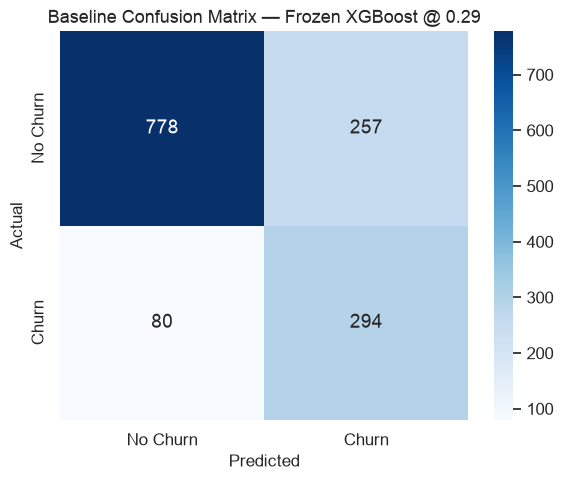

In [7]:
# ── Display confusion matrix ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm_baseline, annot=True, fmt="d", cmap="Blues", ax=ax,
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"],
    annot_kws={"size": 14},
)
ax.set_title("Baseline Confusion Matrix — Frozen XGBoost @ 0.29", fontsize=13)
ax.set_ylabel("Actual")
ax.set_xlabel("Predicted")
plt.tight_layout()
plt.show()

---
## 5. Create Evaluation Scenarios

Create three labeled evaluation batches using the same domain-motivated transformations as V7.2, but applied to the **test set with labels preserved**.

| Scenario | Description |
|---|---|
| **A: stable** | Random sample from test set — control case |
| **B: moderate_population_shift** | Moderate feature shifts (Contract, tenure, MonthlyCharges) |
| **C: strong_population_shift** | Aggressive feature shifts (Contract, tenure, MonthlyCharges, InternetService) |

> **⚠ Limitation**: The label is inherited from the original labeled dataset. Therefore these are *controlled evaluation scenarios* rather than real future production outcomes. The actual churn behavior in a truly shifted population may differ.

In [8]:
def generate_labeled_eval_batch(X_data, y_data, scenario="stable",
                                batch_size=1000, random_state=42):
    """
    Generate a labeled evaluation batch from the test set.

    Unlike V7.2's generate_batch() which operates on X_train without labels,
    this function resamples from the test set while PRESERVING each row's
    original Churn label. Feature transformations follow the same domain
    logic as V7.2.

    Parameters
    ----------
    X_data : pd.DataFrame
        Test set features (X_test).
    y_data : pd.Series
        Test set labels (y_test).
    scenario : str
        One of 'stable', 'moderate_population_shift', 'strong_population_shift'.
    batch_size : int
        Number of rows in the output batch.
    random_state : int
        Random seed for reproducibility.

    Returns
    -------
    X_batch : pd.DataFrame
        Feature batch with same schema as X_data.
    y_batch : pd.Series
        Corresponding labels (inherited from original rows).
    batch_log : dict
        Documentation of what was applied.
    """
    rng = np.random.RandomState(random_state)
    batch_log = {
        "scenario": scenario,
        "batch_size": batch_size,
        "random_state": random_state,
        "source": "test set (held-out, never used for training)",
        "label_source": "original Churn labels preserved from dataset",
        "features_shifted": [],
        "transformations": [],
        "limitation": (
            "The label is inherited from the original labeled dataset. "
            "These are controlled evaluation scenarios, not real future "
            "production outcomes."
        ),
    }

    if scenario == "stable":
        # ── STABLE: Random sample with replacement, no drift ──────────
        idx = rng.choice(len(X_data), size=batch_size, replace=True)
        X_batch = X_data.iloc[idx].reset_index(drop=True).copy()
        y_batch = y_data.iloc[idx].reset_index(drop=True).copy()
        batch_log["description"] = (
            "Random sample with replacement from test set. "
            "No intentional distribution shift. Control case."
        )

    elif scenario == "moderate_population_shift":
        # ── MODERATE SHIFT ────────────────────────────────────────────
        # Same logic as V7.2 mild_shift but applied to test data with labels

        # Step 1: Weighted resample — favor Month-to-month
        weights = np.ones(len(X_data))
        mtm_mask = X_data["Contract"] == "Month-to-month"
        weights[mtm_mask.values] = 2.0
        weights = weights / weights.sum()
        idx = rng.choice(len(X_data), size=batch_size, replace=True, p=weights)
        X_batch = X_data.iloc[idx].reset_index(drop=True).copy()
        y_batch = y_data.iloc[idx].reset_index(drop=True).copy()

        # Step 2: Replace ~20% with low-tenure rows (labels travel with rows)
        n_replace = int(batch_size * 0.20)
        low_tenure_mask = X_data["tenure"] <= 12
        low_tenure_pool_X = X_data[low_tenure_mask]
        low_tenure_pool_y = y_data[low_tenure_mask]
        if len(low_tenure_pool_X) > 0:
            replace_idx = rng.choice(len(low_tenure_pool_X), size=n_replace, replace=True)
            replace_X = low_tenure_pool_X.iloc[replace_idx].reset_index(drop=True)
            replace_y = low_tenure_pool_y.iloc[replace_idx].reset_index(drop=True)
            batch_idx_to_replace = rng.choice(batch_size, size=n_replace, replace=False)
            for i, bi in enumerate(batch_idx_to_replace):
                X_batch.iloc[bi] = replace_X.iloc[i]
                y_batch.iloc[bi] = replace_y.iloc[i]

        # Step 3: Shift MonthlyCharges +$5 (feature-only, label unchanged)
        mc_min = X_data["MonthlyCharges"].min()
        mc_max = X_data["MonthlyCharges"].max()
        X_batch["MonthlyCharges"] = (X_batch["MonthlyCharges"] + 5.0).clip(mc_min, mc_max)

        # Step 4: Recalculate TotalCharges for consistency
        tc_max = X_data["TotalCharges"].max()
        X_batch["TotalCharges"] = (X_batch["tenure"] * X_batch["MonthlyCharges"]).clip(0, tc_max)

        batch_log["features_shifted"] = ["Contract", "tenure", "MonthlyCharges", "TotalCharges"]
        batch_log["transformations"] = [
            {"feature": "Contract", "method": "Weighted resampling (Month-to-month weight=2x)"},
            {"feature": "tenure", "method": "Replace 20% of rows with low-tenure (<=12mo) samples"},
            {"feature": "MonthlyCharges", "method": "Add $5 offset, clip to domain range"},
            {"feature": "TotalCharges", "method": "Recalculated as tenure * MonthlyCharges (clipped)"},
        ]
        batch_log["description"] = (
            "Moderate population shift: Contract skewed toward Month-to-month, "
            "tenure shifted lower, MonthlyCharges increased by $5, "
            "TotalCharges recalculated. Labels preserved from original rows."
        )

    elif scenario == "strong_population_shift":
        # ── STRONG SHIFT ──────────────────────────────────────────────
        # Same logic as V7.2 strong_shift but applied to test data with labels

        # Step 1: Heavy weight for Month-to-month AND Fiber optic
        weights = np.ones(len(X_data))
        mtm_mask = X_data["Contract"] == "Month-to-month"
        fiber_mask = X_data["InternetService"] == "Fiber optic"
        weights[mtm_mask.values] = 3.5
        weights[fiber_mask.values] *= 1.8
        weights = weights / weights.sum()
        idx = rng.choice(len(X_data), size=batch_size, replace=True, p=weights)
        X_batch = X_data.iloc[idx].reset_index(drop=True).copy()
        y_batch = y_data.iloc[idx].reset_index(drop=True).copy()

        # Step 2: Replace ~40% with low-tenure rows (labels travel with rows)
        n_replace = int(batch_size * 0.40)
        low_tenure_mask = X_data["tenure"] <= 12
        low_tenure_pool_X = X_data[low_tenure_mask]
        low_tenure_pool_y = y_data[low_tenure_mask]
        if len(low_tenure_pool_X) > 0:
            replace_idx = rng.choice(len(low_tenure_pool_X), size=n_replace, replace=True)
            replace_X = low_tenure_pool_X.iloc[replace_idx].reset_index(drop=True)
            replace_y = low_tenure_pool_y.iloc[replace_idx].reset_index(drop=True)
            batch_idx_to_replace = rng.choice(batch_size, size=n_replace, replace=False)
            for i, bi in enumerate(batch_idx_to_replace):
                X_batch.iloc[bi] = replace_X.iloc[i]
                y_batch.iloc[bi] = replace_y.iloc[i]

        # Step 3: Shift MonthlyCharges +$12
        mc_min = X_data["MonthlyCharges"].min()
        mc_max = X_data["MonthlyCharges"].max()
        X_batch["MonthlyCharges"] = (X_batch["MonthlyCharges"] + 12.0).clip(mc_min, mc_max)

        # Step 4: Recalculate TotalCharges
        tc_max = X_data["TotalCharges"].max()
        X_batch["TotalCharges"] = (X_batch["tenure"] * X_batch["MonthlyCharges"]).clip(0, tc_max)

        batch_log["features_shifted"] = [
            "Contract", "tenure", "MonthlyCharges", "TotalCharges", "InternetService"
        ]
        batch_log["transformations"] = [
            {"feature": "Contract", "method": "Weighted resampling (Month-to-month weight=3.5x)"},
            {"feature": "tenure", "method": "Replace 40% of rows with low-tenure (<=12mo) samples"},
            {"feature": "MonthlyCharges", "method": "Add $12 offset, clip to domain range"},
            {"feature": "TotalCharges", "method": "Recalculated as tenure * MonthlyCharges (clipped)"},
            {"feature": "InternetService", "method": "Weighted resampling (Fiber optic weight=1.8x)"},
        ]
        batch_log["description"] = (
            "Strong population shift: Contract heavily skewed toward Month-to-month, "
            "tenure shifted very low, MonthlyCharges increased by $12, "
            "InternetService shifted toward Fiber optic. Labels preserved from original rows."
        )
    else:
        raise ValueError(f"Unknown scenario: {scenario}")

    return X_batch, y_batch, batch_log


print("generate_labeled_eval_batch() defined. ✓")
print()
print("Key difference from V7.2 generate_batch():")
print("  - Resamples from TEST set (not training set)")
print("  - Preserves original Churn labels for each resampled row")
print("  - Same domain-motivated feature transformations")

generate_labeled_eval_batch() defined. ✓

Key difference from V7.2 generate_batch():
  - Resamples from TEST set (not training set)
  - Preserves original Churn labels for each resampled row
  - Same domain-motivated feature transformations


In [9]:
# ── Generate all three evaluation scenarios ───────────────────────────
EVAL_BATCH_SIZE = 1000

X_eval_a, y_eval_a, log_a = generate_labeled_eval_batch(
    X_test, y_test, scenario="stable",
    batch_size=EVAL_BATCH_SIZE, random_state=101
)

X_eval_b, y_eval_b, log_b = generate_labeled_eval_batch(
    X_test, y_test, scenario="moderate_population_shift",
    batch_size=EVAL_BATCH_SIZE, random_state=202
)

X_eval_c, y_eval_c, log_c = generate_labeled_eval_batch(
    X_test, y_test, scenario="strong_population_shift",
    batch_size=EVAL_BATCH_SIZE, random_state=303
)

scenarios = {
    "A_stable": (X_eval_a, y_eval_a, log_a),
    "B_moderate_shift": (X_eval_b, y_eval_b, log_b),
    "C_strong_shift": (X_eval_c, y_eval_c, log_c),
}

for name, (X_s, y_s, log_s) in scenarios.items():
    print(f"Scenario {name}")
    print(f"  Rows          : {len(X_s):,}")
    print(f"  Features      : {X_s.shape[1]}")
    print(f"  Churn rate    : {y_s.mean():.4f}")
    print(f"  Description   : {log_s['description'][:80]}...")
    print(f"  ⚠ Limitation  : {log_s['limitation'][:80]}...")
    print()

Scenario A_stable
  Rows          : 1,000
  Features      : 19
  Churn rate    : 0.2630
  Description   : Random sample with replacement from test set. No intentional distribution shift....
  ⚠ Limitation  : The label is inherited from the original labeled dataset. These are controlled e...

Scenario B_moderate_shift
  Rows          : 1,000
  Features      : 19
  Churn rate    : 0.3530
  Description   : Moderate population shift: Contract skewed toward Month-to-month, tenure shifted...
  ⚠ Limitation  : The label is inherited from the original labeled dataset. These are controlled e...

Scenario C_strong_shift
  Rows          : 1,000
  Features      : 19
  Churn rate    : 0.4210
  Description   : Strong population shift: Contract heavily skewed toward Month-to-month, tenure s...
  ⚠ Limitation  : The label is inherited from the original labeled dataset. These are controlled e...



---
## 6. Run Model on Each Batch

For each evaluation batch, run the frozen preprocessing + XGBoost pipeline, extract probabilities, and apply threshold 0.29.

```
X_batch → frozen preprocessing → frozen XGBoost → probability → threshold 0.29 → predicted churn
```

In [10]:
# ── Run frozen model on each scenario ─────────────────────────────────
scenario_predictions = {}

for name, (X_s, y_s, log_s) in scenarios.items():
    # Get probabilities from frozen pipeline
    y_prob = model_v4.predict_proba(X_s)[:, 1]

    # Apply frozen threshold
    y_pred = (y_prob >= THRESHOLD).astype(int)

    scenario_predictions[name] = {
        "y_true": y_s,
        "y_prob": y_prob,
        "y_pred": y_pred,
        "log": log_s,
    }

    print(f"Scenario {name}:")
    print(f"  Predictions generated : {len(y_pred):,}")
    print(f"  Predicted churn rate  : {y_pred.mean():.4f}")
    print(f"  Actual churn rate     : {y_s.mean():.4f}")
    print(f"  Prob range            : [{y_prob.min():.4f}, {y_prob.max():.4f}]")
    print()

Scenario A_stable:
  Predictions generated : 1,000
  Predicted churn rate  : 0.4100
  Actual churn rate     : 0.2630
  Prob range            : [0.0092, 0.9085]

Scenario B_moderate_shift:
  Predictions generated : 1,000
  Predicted churn rate  : 0.5150
  Actual churn rate     : 0.3530
  Prob range            : [0.0092, 0.9037]

Scenario C_strong_shift:
  Predictions generated : 1,000
  Predicted churn rate  : 0.6270
  Actual churn rate     : 0.4210
  Prob range            : [0.0099, 0.9107]



---
## 7. Calculate Performance Metrics

For baseline and every evaluation scenario, calculate:
- Accuracy, Precision, Recall, F1, ROC-AUC
- TP, TN, FP, FN and confusion matrix

In [11]:
def calculate_metrics(y_true, y_pred, y_prob, scenario_name):
    """Calculate all performance metrics for a scenario."""
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    auc = roc_auc_score(y_true, y_prob)

    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    return {
        "scenario": scenario_name,
        "accuracy": round(acc, 4),
        "precision": round(prec, 4),
        "recall": round(rec, 4),
        "f1": round(f1, 4),
        "roc_auc": round(auc, 4),
        "tp": int(tp),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "confusion_matrix": cm.tolist(),
    }


# ── Calculate metrics for all scenarios ───────────────────────────────
all_metrics = {"baseline": baseline_metrics}
all_metrics["baseline"]["confusion_matrix"] = cm_baseline.tolist()

for name, preds in scenario_predictions.items():
    all_metrics[name] = calculate_metrics(
        preds["y_true"], preds["y_pred"], preds["y_prob"], name
    )

# ── Display results table ─────────────────────────────────────────────
metrics_df = pd.DataFrame([
    {k: v for k, v in m.items() if k != "confusion_matrix"}
    for m in all_metrics.values()
]).set_index("scenario")

print("PERFORMANCE METRICS — All Scenarios")
print("=" * 80)
print(metrics_df[["accuracy", "precision", "recall", "f1", "roc_auc"]].to_string())
print()
print(metrics_df[["tp", "tn", "fp", "fn"]].to_string())

PERFORMANCE METRICS — All Scenarios
                  accuracy  precision  recall      f1  roc_auc
scenario                                                      
baseline            0.7608     0.5336  0.7861  0.6357   0.8490
A_stable            0.7430     0.5073  0.7909  0.6181   0.8330
B_moderate_shift    0.7120     0.5631  0.8215  0.6682   0.8103
C_strong_shift      0.6680     0.5710  0.8504  0.6832   0.7960

                   tp   tn   fp  fn
scenario                           
baseline          294  778  257  80
A_stable          208  535  202  55
B_moderate_shift  290  422  225  63
C_strong_shift    358  310  269  63


---
## 8. Calculate Performance Change

For every scenario, compare against baseline:
- **Absolute change** = current − baseline
- **Percentage change** = (current − baseline) / baseline × 100

This is a performance change measurement, NOT a statistical significance test.

In [12]:
# ── Calculate changes vs baseline ─────────────────────────────────────
COMPARISON_METRICS = ["accuracy", "precision", "recall", "f1", "roc_auc"]

change_records = []
for scenario_name in ["A_stable", "B_moderate_shift", "C_strong_shift"]:
    record = {"scenario": scenario_name}
    for metric in COMPARISON_METRICS:
        baseline_val = baseline_metrics[metric]
        current_val = all_metrics[scenario_name][metric]
        abs_change = round(current_val - baseline_val, 4)
        pct_change = round((current_val - baseline_val) / baseline_val * 100, 2) if baseline_val != 0 else 0.0
        record[f"{metric}_absolute_change"] = abs_change
        record[f"{metric}_percentage_change"] = pct_change
    change_records.append(record)

change_df = pd.DataFrame(change_records).set_index("scenario")

print("PERFORMANCE CHANGE vs BASELINE")
print("=" * 90)
print()
for metric in COMPARISON_METRICS:
    print(f"  {metric.upper()}:")
    print(f"    Baseline = {baseline_metrics[metric]:.4f}")
    for rec in change_records:
        name = rec["scenario"]
        current = all_metrics[name][metric]
        abs_ch = rec[f"{metric}_absolute_change"]
        pct_ch = rec[f"{metric}_percentage_change"]
        print(f"    {name:25s} : {current:.4f}  (Δ {abs_ch:+.4f}, {pct_ch:+.2f}%)")
    print()

PERFORMANCE CHANGE vs BASELINE

  ACCURACY:
    Baseline = 0.7608
    A_stable                  : 0.7430  (Δ -0.0178, -2.34%)
    B_moderate_shift          : 0.7120  (Δ -0.0488, -6.41%)
    C_strong_shift            : 0.6680  (Δ -0.0928, -12.20%)

  PRECISION:
    Baseline = 0.5336
    A_stable                  : 0.5073  (Δ -0.0263, -4.93%)
    B_moderate_shift          : 0.5631  (Δ +0.0295, +5.53%)
    C_strong_shift            : 0.5710  (Δ +0.0374, +7.01%)

  RECALL:
    Baseline = 0.7861
    A_stable                  : 0.7909  (Δ +0.0048, +0.61%)
    B_moderate_shift          : 0.8215  (Δ +0.0354, +4.50%)
    C_strong_shift            : 0.8504  (Δ +0.0643, +8.18%)

  F1:
    Baseline = 0.6357
    A_stable                  : 0.6181  (Δ -0.0176, -2.77%)
    B_moderate_shift          : 0.6682  (Δ +0.0325, +5.11%)
    C_strong_shift            : 0.6832  (Δ +0.0475, +7.47%)

  ROC_AUC:
    Baseline = 0.8490
    A_stable                  : 0.8330  (Δ -0.0160, -1.88%)
    B_moderate_shift 

---
## 9. Performance Degradation Rule

**Primary metric**: F1 Score

**Rule**: If F1 degradation ≥ 10% → `DEGRADED`, else → `STABLE`

> **Note**: The 10% threshold is a **project-specific monitoring threshold**, chosen as a reasonable default for this experiment. It is NOT a universal industry standard. In practice, this threshold would be calibrated based on business requirements, cost-of-error analysis, and domain expertise.

All other metrics are reported regardless of the degradation status.

In [13]:
# ── Apply degradation rule ────────────────────────────────────────────
DEGRADATION_THRESHOLD_PCT = 10.0  # Percentage

degradation_results = {}
for rec in change_records:
    scenario = rec["scenario"]
    f1_pct_change = rec["f1_percentage_change"]

    # Degradation = negative percentage change exceeding threshold
    if f1_pct_change <= -DEGRADATION_THRESHOLD_PCT:
        status = "DEGRADED"
    else:
        status = "STABLE"

    degradation_results[scenario] = {
        "f1_baseline": baseline_metrics["f1"],
        "f1_current": all_metrics[scenario]["f1"],
        "f1_absolute_change": rec["f1_absolute_change"],
        "f1_percentage_change": f1_pct_change,
        "degradation_threshold_pct": DEGRADATION_THRESHOLD_PCT,
        "performance_status": status,
    }

print("PERFORMANCE DEGRADATION ASSESSMENT")
print("=" * 70)
print(f"  Primary metric         : F1 Score")
print(f"  Degradation threshold  : {DEGRADATION_THRESHOLD_PCT}% decline")
print(f"  Baseline F1            : {baseline_metrics['f1']:.4f}")
print()

for scenario, result in degradation_results.items():
    status_icon = "🔴" if result["performance_status"] == "DEGRADED" else "🟢"
    print(f"  {scenario}:")
    print(f"    F1 = {result['f1_current']:.4f}  "
          f"(Δ {result['f1_absolute_change']:+.4f}, "
          f"{result['f1_percentage_change']:+.2f}%)")
    print(f"    Status: {status_icon} {result['performance_status']}")
    print()

print("-" * 70)
print("  NOTE: The 10% threshold is a project-specific monitoring threshold.")
print("  It would normally be calibrated using business requirements.")
print("  All metrics are reported regardless of degradation status.")

PERFORMANCE DEGRADATION ASSESSMENT
  Primary metric         : F1 Score
  Degradation threshold  : 10.0% decline
  Baseline F1            : 0.6357

  A_stable:
    F1 = 0.6181  (Δ -0.0176, -2.77%)
    Status: 🟢 STABLE

  B_moderate_shift:
    F1 = 0.6682  (Δ +0.0325, +5.11%)
    Status: 🟢 STABLE

  C_strong_shift:
    F1 = 0.6832  (Δ +0.0475, +7.47%)
    Status: 🟢 STABLE

----------------------------------------------------------------------
  NOTE: The 10% threshold is a project-specific monitoring threshold.
  It would normally be calibrated using business requirements.
  All metrics are reported regardless of degradation status.


---
## 10. Visualizations

Six charts covering metric comparisons, confusion matrices, and degradation percentages.

In [14]:
# ── Visualization setup ───────────────────────────────────────────────
scenario_labels = ["Baseline", "A: Stable", "B: Moderate\nShift", "C: Strong\nShift"]
scenario_keys = ["baseline", "A_stable", "B_moderate_shift", "C_strong_shift"]
colors = ["#2196F3", "#4CAF50", "#FF9800", "#F44336"]

def get_metric_values(metric_name):
    return [all_metrics[k][metric_name] for k in scenario_keys]

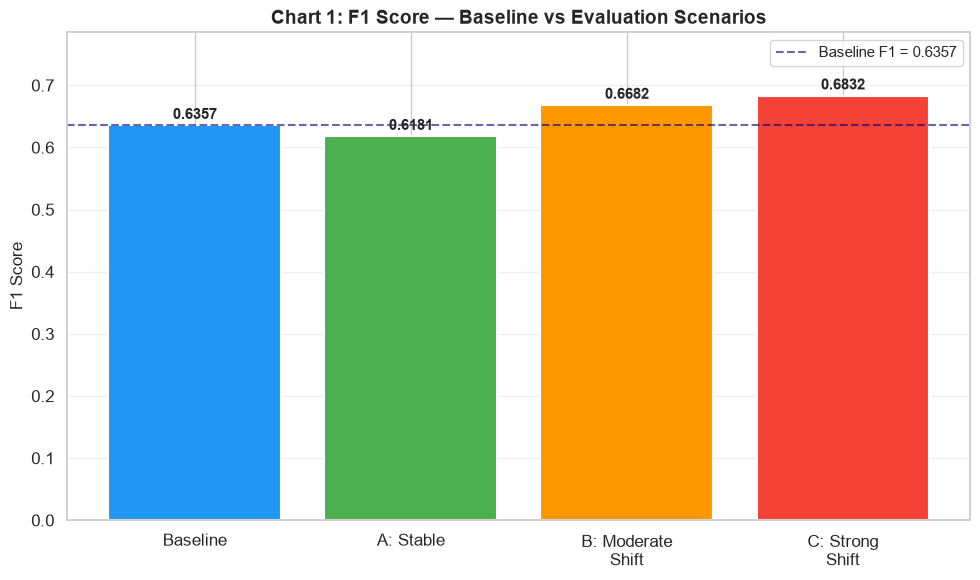

In [15]:
# ── Chart 1: F1 Score Comparison ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
vals = get_metric_values("f1")
bars = ax.bar(scenario_labels, vals, color=colors, edgecolor="white", linewidth=1.5)
ax.axhline(y=baseline_metrics["f1"], color="navy", linestyle="--", alpha=0.6,
           label=f"Baseline F1 = {baseline_metrics['f1']:.4f}")
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{val:.4f}", ha="center", va="bottom", fontweight="bold", fontsize=11)
ax.set_title("Chart 1: F1 Score — Baseline vs Evaluation Scenarios", fontsize=14, fontweight="bold")
ax.set_ylabel("F1 Score")
ax.set_ylim(0, max(vals) * 1.15)
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

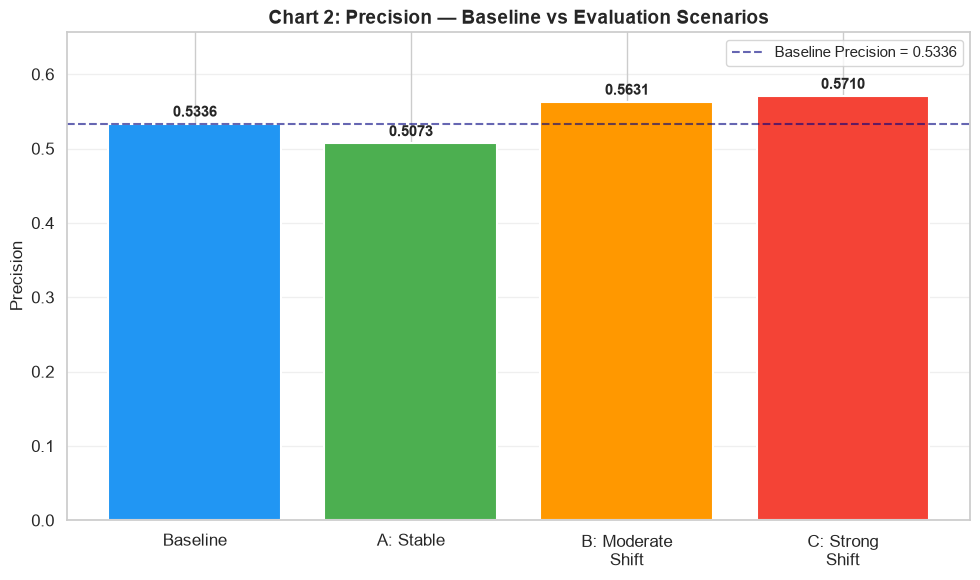

In [16]:
# ── Chart 2: Precision Comparison ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
vals = get_metric_values("precision")
bars = ax.bar(scenario_labels, vals, color=colors, edgecolor="white", linewidth=1.5)
ax.axhline(y=baseline_metrics["precision"], color="navy", linestyle="--", alpha=0.6,
           label=f"Baseline Precision = {baseline_metrics['precision']:.4f}")
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{val:.4f}", ha="center", va="bottom", fontweight="bold", fontsize=11)
ax.set_title("Chart 2: Precision — Baseline vs Evaluation Scenarios", fontsize=14, fontweight="bold")
ax.set_ylabel("Precision")
ax.set_ylim(0, max(vals) * 1.15)
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

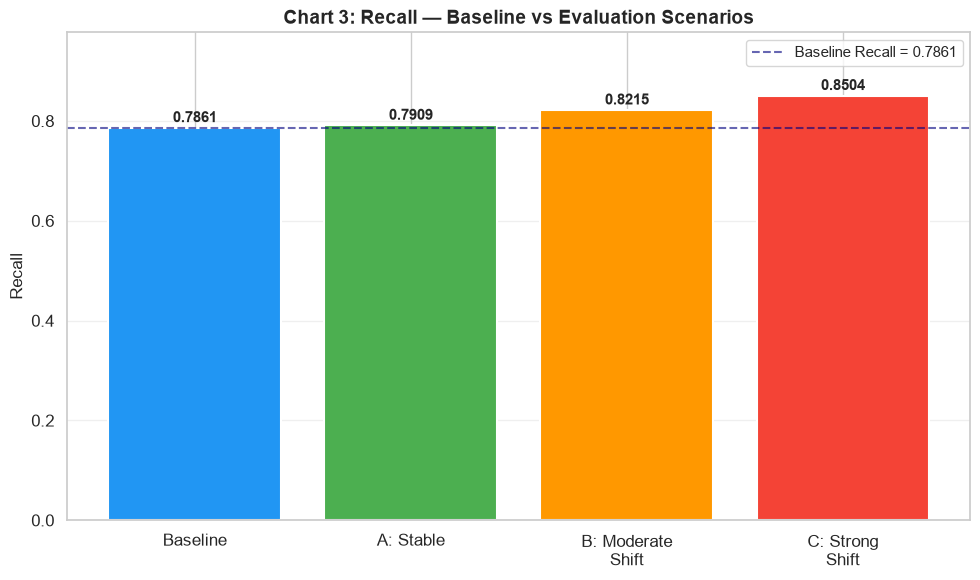

In [17]:
# ── Chart 3: Recall Comparison ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
vals = get_metric_values("recall")
bars = ax.bar(scenario_labels, vals, color=colors, edgecolor="white", linewidth=1.5)
ax.axhline(y=baseline_metrics["recall"], color="navy", linestyle="--", alpha=0.6,
           label=f"Baseline Recall = {baseline_metrics['recall']:.4f}")
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{val:.4f}", ha="center", va="bottom", fontweight="bold", fontsize=11)
ax.set_title("Chart 3: Recall — Baseline vs Evaluation Scenarios", fontsize=14, fontweight="bold")
ax.set_ylabel("Recall")
ax.set_ylim(0, max(vals) * 1.15)
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

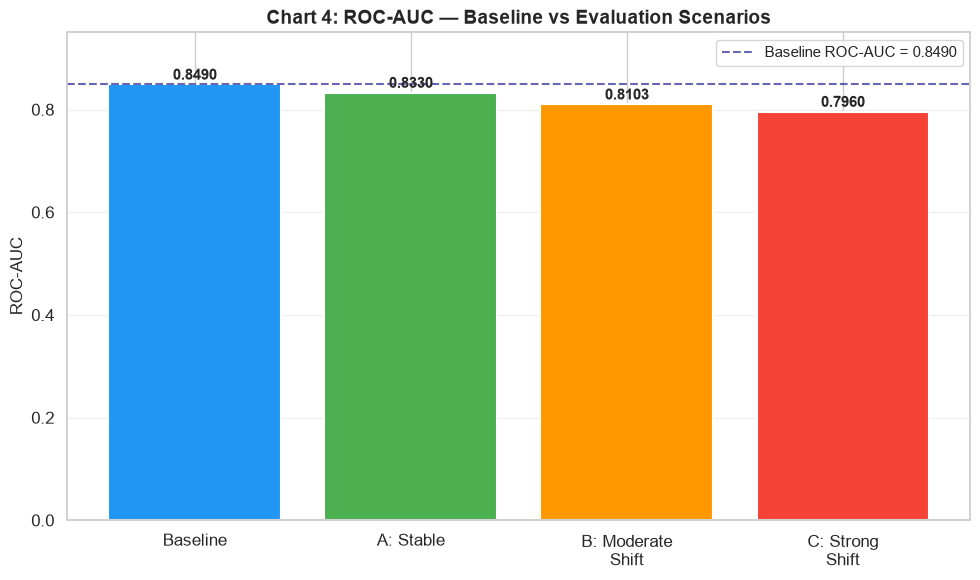

In [18]:
# ── Chart 4: ROC-AUC Comparison ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
vals = get_metric_values("roc_auc")
bars = ax.bar(scenario_labels, vals, color=colors, edgecolor="white", linewidth=1.5)
ax.axhline(y=baseline_metrics["roc_auc"], color="navy", linestyle="--", alpha=0.6,
           label=f"Baseline ROC-AUC = {baseline_metrics['roc_auc']:.4f}")
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f"{val:.4f}", ha="center", va="bottom", fontweight="bold", fontsize=11)
ax.set_title("Chart 4: ROC-AUC — Baseline vs Evaluation Scenarios", fontsize=14, fontweight="bold")
ax.set_ylabel("ROC-AUC")
ax.set_ylim(0, max(vals) * 1.12)
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

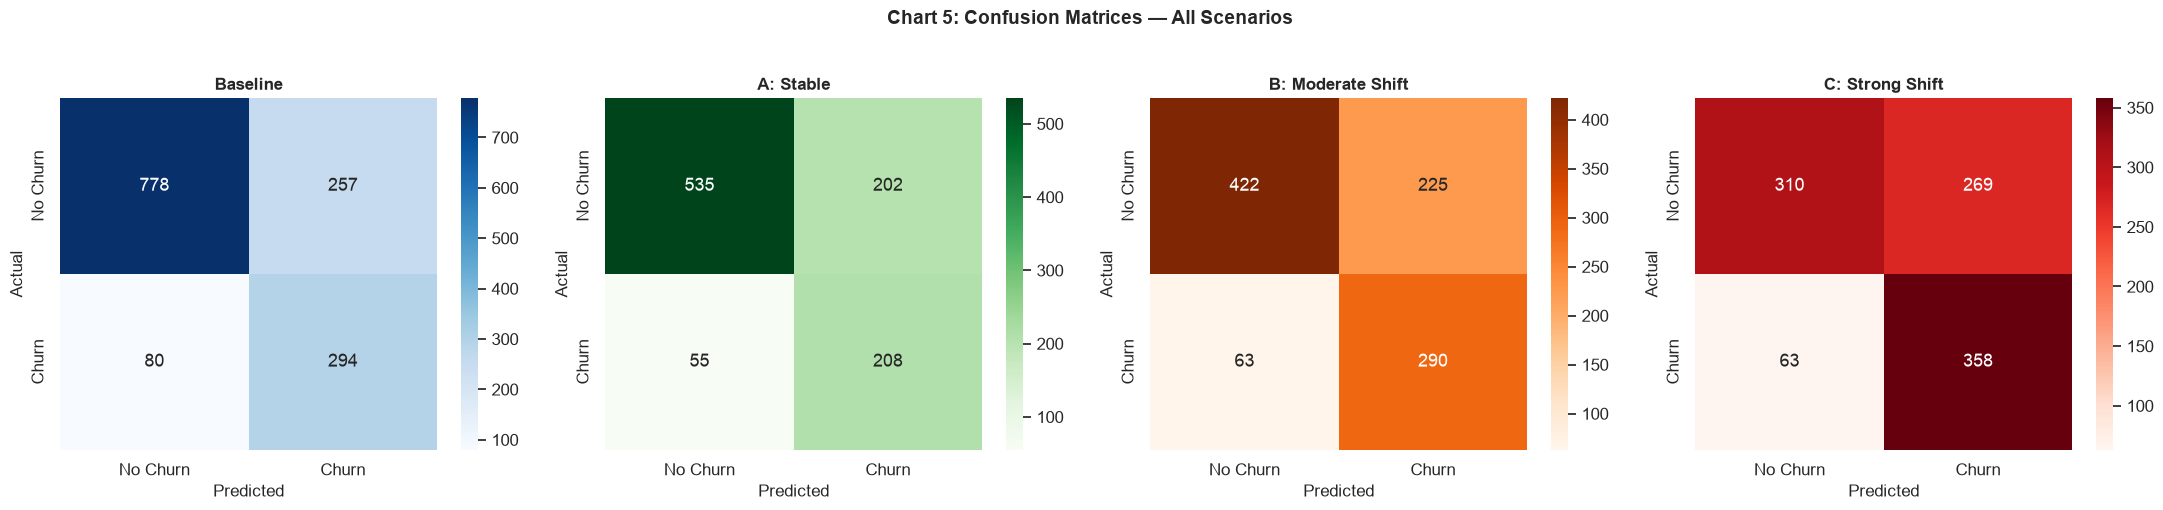

In [19]:
# ── Chart 5: Confusion Matrices for Each Scenario ────────────────────
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

cm_data = {
    "Baseline": np.array(all_metrics["baseline"]["confusion_matrix"]),
    "A: Stable": np.array(all_metrics["A_stable"]["confusion_matrix"]),
    "B: Moderate Shift": np.array(all_metrics["B_moderate_shift"]["confusion_matrix"]),
    "C: Strong Shift": np.array(all_metrics["C_strong_shift"]["confusion_matrix"]),
}

for ax, (title, cm), color in zip(axes, cm_data.items(), ["Blues", "Greens", "Oranges", "Reds"]):
    sns.heatmap(
        cm, annot=True, fmt="d", cmap=color, ax=ax,
        xticklabels=["No Churn", "Churn"],
        yticklabels=["No Churn", "Churn"],
        annot_kws={"size": 13},
    )
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_ylabel("Actual")
    ax.set_xlabel("Predicted")

plt.suptitle("Chart 5: Confusion Matrices — All Scenarios", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

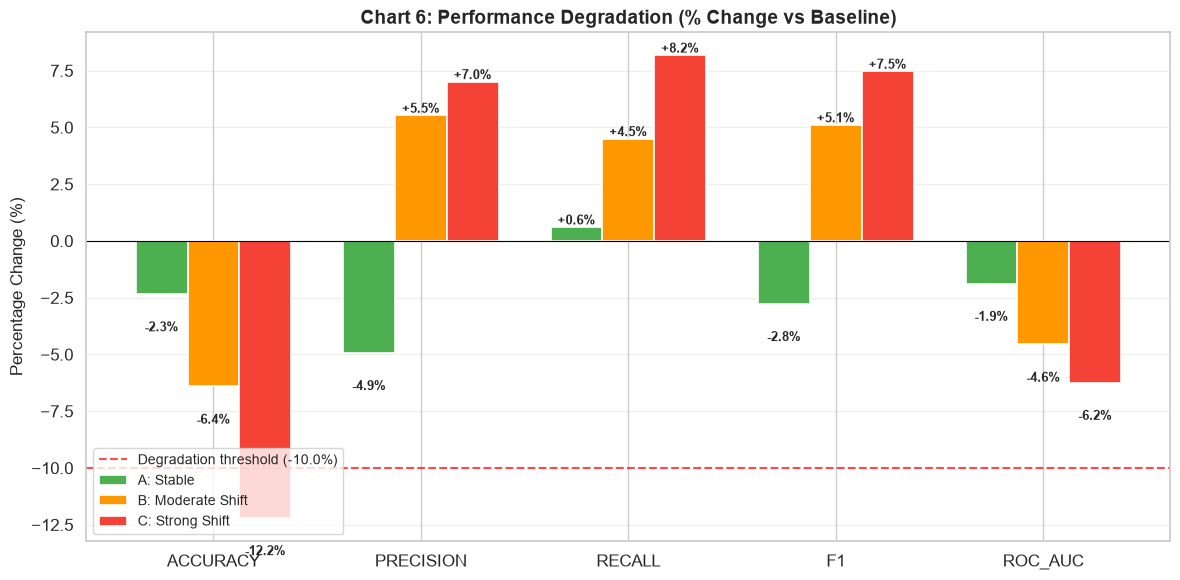

In [20]:
# ── Chart 6: Performance Degradation Percentage ──────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

degradation_metrics = ["accuracy", "precision", "recall", "f1", "roc_auc"]
x = np.arange(len(degradation_metrics))
width = 0.25

scenario_names_short = ["A: Stable", "B: Moderate Shift", "C: Strong Shift"]
scenario_change_keys = ["A_stable", "B_moderate_shift", "C_strong_shift"]
bar_colors = ["#4CAF50", "#FF9800", "#F44336"]

for i, (sname, skey, color) in enumerate(zip(scenario_names_short, scenario_change_keys, bar_colors)):
    pct_changes = [change_df.loc[skey, f"{m}_percentage_change"] for m in degradation_metrics]
    bars = ax.bar(x + i * width, pct_changes, width, label=sname, color=color,
                  edgecolor="white", linewidth=1.2)
    for bar, val in zip(bars, pct_changes):
        y_pos = bar.get_height() if bar.get_height() >= 0 else bar.get_height() - 1.2
        va = "bottom" if bar.get_height() >= 0 else "top"
        ax.text(bar.get_x() + bar.get_width()/2, y_pos,
                f"{val:+.1f}%", ha="center", va=va, fontsize=9, fontweight="bold")

ax.axhline(y=0, color="black", linewidth=0.8)
ax.axhline(y=-DEGRADATION_THRESHOLD_PCT, color="red", linestyle="--", alpha=0.7,
           label=f"Degradation threshold (-{DEGRADATION_THRESHOLD_PCT}%)")
ax.set_xticks(x + width)
ax.set_xticklabels([m.upper() for m in degradation_metrics])
ax.set_ylabel("Percentage Change (%)")
ax.set_title("Chart 6: Performance Degradation (% Change vs Baseline)", fontsize=14, fontweight="bold")
ax.legend(fontsize=10, loc="lower left")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

---
## 11. Interpretation

In [21]:
# ── Scenario-by-scenario interpretation ───────────────────────────────
print("=" * 80)
print("  V8 INTERPRETATION — Model Performance Under Population Shifts")
print("=" * 80)

# Scenario A
print()
print("SCENARIO A — Stable (Control)")
print("-" * 60)
f1_a = all_metrics["A_stable"]["f1"]
f1_change_a = change_df.loc["A_stable", "f1_percentage_change"]
if abs(f1_change_a) < 2:
    print(f"  F1 = {f1_a:.4f} ({f1_change_a:+.2f}% vs baseline)")
    print("  ✓ Performance remained stable, as expected for a control scenario.")
    print("  This confirms the model produces consistent results when the")
    print("  population distribution does not change meaningfully.")
else:
    print(f"  F1 = {f1_a:.4f} ({f1_change_a:+.2f}% vs baseline)")
    print("  Note: Some variation observed due to resampling with replacement.")
    print("  Random sampling can introduce small fluctuations even without drift.")

# Scenario B
print()
print("SCENARIO B — Moderate Population Shift")
print("-" * 60)
f1_b = all_metrics["B_moderate_shift"]["f1"]
f1_change_b = change_df.loc["B_moderate_shift", "f1_percentage_change"]
status_b = degradation_results["B_moderate_shift"]["performance_status"]
print(f"  F1 = {f1_b:.4f} ({f1_change_b:+.2f}% vs baseline)")
print(f"  Status: {status_b}")
if f1_change_b < -5:
    print("  Performance shows notable decline under moderate population shift.")
    print("  The shifts in Contract, tenure, and MonthlyCharges are affecting")
    print("  the model's ability to correctly classify churn.")
elif f1_change_b < 0:
    print("  Performance shows minor decline — the model is somewhat robust")
    print("  to moderate population changes.")
else:
    print("  Performance maintained or improved — the model is robust")
    print("  to moderate population shifts in these features.")

# Scenario C
print()
print("SCENARIO C — Strong Population Shift")
print("-" * 60)
f1_c = all_metrics["C_strong_shift"]["f1"]
f1_change_c = change_df.loc["C_strong_shift", "f1_percentage_change"]
status_c = degradation_results["C_strong_shift"]["performance_status"]
print(f"  F1 = {f1_c:.4f} ({f1_change_c:+.2f}% vs baseline)")
print(f"  Status: {status_c}")
if f1_change_c < -10:
    print("  Significant performance degradation under strong population shift.")
    print("  The aggressive changes in Contract mix, tenure distribution,")
    print("  MonthlyCharges, and InternetService composition have materially")
    print("  affected the model's predictive effectiveness.")
elif f1_change_c < -5:
    print("  Moderate performance decline under strong population shift.")
    print("  While not crossing the degradation threshold, this warrants monitoring.")
else:
    print("  Model shows resilience even under strong population shifts.")

# Drift vs Performance Degradation
print()
print("=" * 80)
print("  KEY DISTINCTION: DATA DRIFT vs MODEL PERFORMANCE DEGRADATION")
print("=" * 80)
print()
print("  DATA DRIFT (V7):")
print("    - Measures whether input feature distributions have changed")
print("    - Does NOT require labels")
print("    - Drift ≠ automatically bad model")
print("    - Example: Average MonthlyCharges increased by $5")
print()
print("  MODEL PERFORMANCE DEGRADATION (V8):")
print("    - Measures whether predictions match actual outcomes less accurately")
print("    - REQUIRES labels (ground truth)")
print("    - Performance degradation = evidence that predictions are becoming")
print("      less effective on labeled outcomes")
print("    - Example: F1 dropped from 0.64 to 0.55")
print()
print("  A model can experience drift WITHOUT degradation:")
print("    - If shifted features are not critical to the decision boundary")
print("    - If the model generalizes well to the shifted region")
print()
print("  A model can degrade WITHOUT observable drift:")
print("    - If concept drift occurs (relationship between X and y changes)")
print("    - This would not be detectable via feature-level drift alone")
print()
print("  BOTH V7 and V8 are needed for comprehensive monitoring.")

  V8 INTERPRETATION — Model Performance Under Population Shifts

SCENARIO A — Stable (Control)
------------------------------------------------------------
  F1 = 0.6181 (-2.77% vs baseline)
  Note: Some variation observed due to resampling with replacement.
  Random sampling can introduce small fluctuations even without drift.

SCENARIO B — Moderate Population Shift
------------------------------------------------------------
  F1 = 0.6682 (+5.11% vs baseline)
  Status: STABLE
  Performance maintained or improved — the model is robust
  to moderate population shifts in these features.

SCENARIO C — Strong Population Shift
------------------------------------------------------------
  F1 = 0.6832 (+7.47% vs baseline)
  Status: STABLE
  Model shows resilience even under strong population shifts.

  KEY DISTINCTION: DATA DRIFT vs MODEL PERFORMANCE DEGRADATION

  DATA DRIFT (V7):
    - Measures whether input feature distributions have changed
    - Does NOT require labels
    - Drift ≠ au

---
## 12. Save Artifacts

Save all V8 results to `artifacts/monitoring/` with `_v8` suffix. V7 artifacts are NOT modified.

In [22]:
# ── 1. Baseline metrics JSON ──────────────────────────────────────────
baseline_save = {
    "version": "V8",
    "description": "Baseline model performance metrics on held-out test set",
    "model": "churn_xgboost_v4_tuned.joblib",
    "threshold": THRESHOLD,
    "evaluation_data": {
        "source": "held-out test set (test_size=0.2, random_state=42, stratify=y)",
        "rows": len(y_test),
        "features": X_test.shape[1],
        "churn_rate": round(float(y_test.mean()), 4),
    },
    "metrics": baseline_metrics,
    "created_at": datetime.now().isoformat(),
}

baseline_path = MONITORING_DIR / "performance_baseline_v8.json"
with open(baseline_path, "w") as f:
    json.dump(baseline_save, f, indent=2)
print(f"✓ Saved: {baseline_path}")

# ── 2. Performance results CSV ───────────────────────────────────────
results_records = []
for scenario_name in ["baseline", "A_stable", "B_moderate_shift", "C_strong_shift"]:
    m = all_metrics[scenario_name]
    record = {k: v for k, v in m.items() if k != "confusion_matrix"}
    results_records.append(record)

results_csv_path = MONITORING_DIR / "performance_results_v8.csv"
pd.DataFrame(results_records).to_csv(results_csv_path, index=False)
print(f"✓ Saved: {results_csv_path}")

# ── 3. Performance metadata JSON ────────────────────────────────────
metadata = {
    "version": "V8",
    "experiment": "Model Performance Monitoring",
    "description": (
        "Evaluate whether the frozen XGBoost model's predictive performance "
        "has degraded on labeled evaluation data under controlled population shifts."
    ),
    "model_artifact": str(MODEL_PATH),
    "model_hash": model_hash_before,
    "threshold": THRESHOLD,
    "degradation_rule": {
        "primary_metric": "F1",
        "threshold_pct": DEGRADATION_THRESHOLD_PCT,
        "rule": "F1 degradation >= 10% -> DEGRADED, else STABLE",
        "note": "Project-specific threshold, not a universal industry standard.",
    },
    "evaluation_data": {
        "source": "data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv",
        "split": "test_size=0.2, random_state=42, stratify=y",
        "test_rows": len(y_test),
        "train_rows": len(y_train),
    },
    "scenarios": {
        name: {
            "description": preds["log"]["description"],
            "batch_size": len(preds["y_true"]),
            "churn_rate": round(float(preds["y_true"].mean()), 4),
            "features_shifted": preds["log"]["features_shifted"],
            "limitation": preds["log"]["limitation"],
        }
        for name, preds in scenario_predictions.items()
    },
    "degradation_results": degradation_results,
    "performance_changes": change_records,
    "created_at": datetime.now().isoformat(),
}

metadata_path = MONITORING_DIR / "performance_metadata_v8.json"
with open(metadata_path, "w") as f:
    json.dump(metadata, f, indent=2, default=str)
print(f"✓ Saved: {metadata_path}")

# ── 4. Confusion matrices JSON ──────────────────────────────────────
cm_save = {
    "version": "V8",
    "description": "Confusion matrices for baseline and all evaluation scenarios",
    "threshold": THRESHOLD,
    "matrices": {
        name: {
            "confusion_matrix": m["confusion_matrix"],
            "labels": ["No Churn (0)", "Churn (1)"],
            "format": "[[TN, FP], [FN, TP]]",
        }
        for name, m in all_metrics.items()
    },
    "created_at": datetime.now().isoformat(),
}

cm_path = MONITORING_DIR / "confusion_matrices_v8.json"
with open(cm_path, "w") as f:
    json.dump(cm_save, f, indent=2)
print(f"✓ Saved: {cm_path}")

print()
print("All V8 artifacts saved. V7 artifacts NOT modified.")

✓ Saved: /Users/shubhamswaraj/Desktop/PLACEMENT/IntelliPulse/artifacts/monitoring/performance_baseline_v8.json
✓ Saved: /Users/shubhamswaraj/Desktop/PLACEMENT/IntelliPulse/artifacts/monitoring/performance_results_v8.csv
✓ Saved: /Users/shubhamswaraj/Desktop/PLACEMENT/IntelliPulse/artifacts/monitoring/performance_metadata_v8.json
✓ Saved: /Users/shubhamswaraj/Desktop/PLACEMENT/IntelliPulse/artifacts/monitoring/confusion_matrices_v8.json

All V8 artifacts saved. V7 artifacts NOT modified.


---
## 13. Validation

Automated PASS/FAIL checks to verify V8 experiment integrity.

In [23]:
# ── Automated Validation ──────────────────────────────────────────────
validation_results = []

def check(name, condition):
    status = "PASS" if condition else "FAIL"
    validation_results.append({"check": name, "status": status})
    icon = "✓" if condition else "✗"
    print(f"  [{status}] {icon} {name}")
    return condition

print("V8 VALIDATION CHECKS")
print("=" * 70)

# 1. Model loaded successfully
check("Model loaded successfully",
      model_v4 is not None and hasattr(model_v4, "predict_proba"))

# 2. Threshold == 0.29
check("Threshold == 0.29",
      THRESHOLD == 0.29)

# 3. Evaluation data contains genuine labels
check("Evaluation data contains genuine labels",
      len(y_test) > 0 and set(y_test.unique()) == {0, 1})

# 4. Target not used as a model feature
check("Target not used as a model feature",
      TARGET_COL not in X_test.columns and TARGET_COL not in X_eval_a.columns)

# 5. Baseline metrics calculated
check("Baseline metrics calculated",
      all(k in baseline_metrics for k in ["accuracy", "precision", "recall", "f1", "roc_auc"]))

# 6. All three scenarios evaluated
check("All three scenarios evaluated",
      all(k in all_metrics for k in ["A_stable", "B_moderate_shift", "C_strong_shift"]))

# 7. All required metrics present
required_metrics = ["accuracy", "precision", "recall", "f1", "roc_auc", "tp", "tn", "fp", "fn"]
all_present = all(
    all(m in all_metrics[s] for m in required_metrics)
    for s in ["baseline", "A_stable", "B_moderate_shift", "C_strong_shift"]
)
check("All required metrics present for all scenarios", all_present)

# 8. Prediction lengths match label lengths
lengths_match = all(
    len(scenario_predictions[s]["y_pred"]) == len(scenario_predictions[s]["y_true"])
    for s in scenario_predictions
)
check("Prediction lengths match label lengths", lengths_match)

# 9. No NaN metrics
no_nan = all(
    not any(np.isnan(v) for v in [all_metrics[s][m] for m in ["accuracy", "precision", "recall", "f1", "roc_auc"]])
    for s in all_metrics
)
check("No NaN metrics", no_nan)

# 10. Probabilities between 0 and 1
probs_valid = all(
    scenario_predictions[s]["y_prob"].min() >= 0 and scenario_predictions[s]["y_prob"].max() <= 1
    for s in scenario_predictions
)
check("Probabilities are between 0 and 1", probs_valid)

# 11. Class predictions are binary
preds_binary = all(
    set(np.unique(scenario_predictions[s]["y_pred"])).issubset({0, 1})
    for s in scenario_predictions
)
check("Class predictions are binary (0 or 1)", preds_binary)

# 12. V7 artifacts unchanged
v7_unchanged = True
for fname, hash_before in v7_hashes_before.items():
    fpath = None
    for f in V7_FILES:
        if f.name == fname:
            fpath = f
            break
    if fpath and fpath.exists():
        hash_after = hashlib.sha256(open(fpath, "rb").read()).hexdigest()
        if hash_after != hash_before:
            v7_unchanged = False
            print(f"    ⚠ CHANGED: {fname}")
check("V7 artifacts unchanged", v7_unchanged)

# 13. XGBoost model unchanged
model_hash_after = hashlib.sha256(open(MODEL_PATH, "rb").read()).hexdigest()
check("XGBoost model file unchanged",
      model_hash_after == model_hash_before)

print()
total = len(validation_results)
passed = sum(1 for v in validation_results if v["status"] == "PASS")
failed = total - passed
print(f"Results: {passed}/{total} PASSED, {failed}/{total} FAILED")
if failed == 0:
    print("✓ All validation checks passed!")
else:
    print("⚠ Some validation checks failed — review above.")

V8 VALIDATION CHECKS
  [PASS] ✓ Model loaded successfully
  [PASS] ✓ Threshold == 0.29
  [PASS] ✓ Evaluation data contains genuine labels
  [PASS] ✓ Target not used as a model feature
  [PASS] ✓ Baseline metrics calculated
  [PASS] ✓ All three scenarios evaluated
  [PASS] ✓ All required metrics present for all scenarios
  [PASS] ✓ Prediction lengths match label lengths
  [PASS] ✓ No NaN metrics
  [PASS] ✓ Probabilities are between 0 and 1
  [PASS] ✓ Class predictions are binary (0 or 1)
  [PASS] ✓ V7 artifacts unchanged
  [PASS] ✓ XGBoost model file unchanged

Results: 13/13 PASSED, 0/13 FAILED
✓ All validation checks passed!


---
## 14. Final V8 Report

In [24]:
# ── Final V8 Report ───────────────────────────────────────────────────
print("=" * 80)
print("  INTELLIPULSE V8 — MODEL PERFORMANCE MONITORING REPORT")
print("=" * 80)
print()

# Baseline
print("  BASELINE (Held-out Test Set, n={:,}):".format(len(y_test)))
print(f"    Accuracy  = {baseline_metrics['accuracy']:.4f}")
print(f"    Precision = {baseline_metrics['precision']:.4f}")
print(f"    Recall    = {baseline_metrics['recall']:.4f}")
print(f"    F1        = {baseline_metrics['f1']:.4f}")
print(f"    ROC-AUC   = {baseline_metrics['roc_auc']:.4f}")
print()

# Scenarios
scenario_display = {
    "A_stable": "STABLE (Scenario A)",
    "B_moderate_shift": "MODERATE SHIFT (Scenario B)",
    "C_strong_shift": "STRONG SHIFT (Scenario C)",
}
for key, display in scenario_display.items():
    m = all_metrics[key]
    ch = next(r for r in change_records if r["scenario"] == key)
    status = degradation_results[key]["performance_status"]
    print(f"  {display}:")
    print(f"    Accuracy  = {m['accuracy']:.4f}  ({ch['accuracy_percentage_change']:+.2f}%)")
    print(f"    Precision = {m['precision']:.4f}  ({ch['precision_percentage_change']:+.2f}%)")
    print(f"    Recall    = {m['recall']:.4f}  ({ch['recall_percentage_change']:+.2f}%)")
    print(f"    F1        = {m['f1']:.4f}  ({ch['f1_percentage_change']:+.2f}%)")
    print(f"    ROC-AUC   = {m['roc_auc']:.4f}  ({ch['roc_auc_percentage_change']:+.2f}%)")
    print()

# Degradation Summary
print("-" * 80)
print("  PERFORMANCE DEGRADATION SUMMARY")
print("-" * 80)
for key, display in scenario_display.items():
    result = degradation_results[key]
    status_icon = "🔴" if result["performance_status"] == "DEGRADED" else "🟢"
    print(f"  {display}:")
    print(f"    F1 change  : {result['f1_absolute_change']:+.4f} ({result['f1_percentage_change']:+.2f}%)")
    print(f"    Status     : {status_icon} {result['performance_status']}")
    print()

# Overall status
any_degraded = any(r["performance_status"] == "DEGRADED" for r in degradation_results.values())
overall_status = "DEGRADED" if any_degraded else "STABLE"
overall_icon = "🔴" if any_degraded else "🟢"
print(f"  OVERALL MONITORING STATUS: {overall_icon} {overall_status}")
print()

# Limitations
print("-" * 80)
print("  LIMITATIONS")
print("-" * 80)
print("  1. Evaluation scenarios use CONTROLLED population shifts, not real")
print("     production data. Labels are inherited from the original dataset.")
print("  2. In production, ground-truth labels may arrive with delay or")
print("     may not be available for all predictions.")
print("  3. The 10% F1 degradation threshold is project-specific and would")
print("     need calibration based on business requirements.")
print("  4. Concept drift (changes in the X→y relationship) cannot be")
print("     simulated with feature-only transformations.")
print("  5. These scenarios demonstrate the MECHANISM of performance")
print("     monitoring — actual production monitoring would use real")
print("     labeled feedback data.")
print("=" * 80)

  INTELLIPULSE V8 — MODEL PERFORMANCE MONITORING REPORT

  BASELINE (Held-out Test Set, n=1,409):
    Accuracy  = 0.7608
    Precision = 0.5336
    Recall    = 0.7861
    F1        = 0.6357
    ROC-AUC   = 0.8490

  STABLE (Scenario A):
    Accuracy  = 0.7430  (-2.34%)
    Precision = 0.5073  (-4.93%)
    Recall    = 0.7909  (+0.61%)
    F1        = 0.6181  (-2.77%)
    ROC-AUC   = 0.8330  (-1.88%)

  MODERATE SHIFT (Scenario B):
    Accuracy  = 0.7120  (-6.41%)
    Precision = 0.5631  (+5.53%)
    Recall    = 0.8215  (+4.50%)
    F1        = 0.6682  (+5.11%)
    ROC-AUC   = 0.8103  (-4.56%)

  STRONG SHIFT (Scenario C):
    Accuracy  = 0.6680  (-12.20%)
    Precision = 0.5710  (+7.01%)
    Recall    = 0.8504  (+8.18%)
    F1        = 0.6832  (+7.47%)
    ROC-AUC   = 0.7960  (-6.24%)

--------------------------------------------------------------------------------
  PERFORMANCE DEGRADATION SUMMARY
--------------------------------------------------------------------------------
  STABLE